<a href="https://colab.research.google.com/github/sethamonyarkoh/DataMining-Portfolio/blob/main/COMP590_Module_7_DQ_7_1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

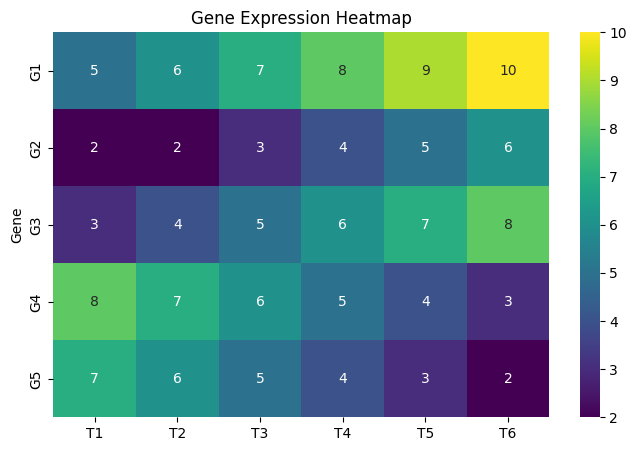

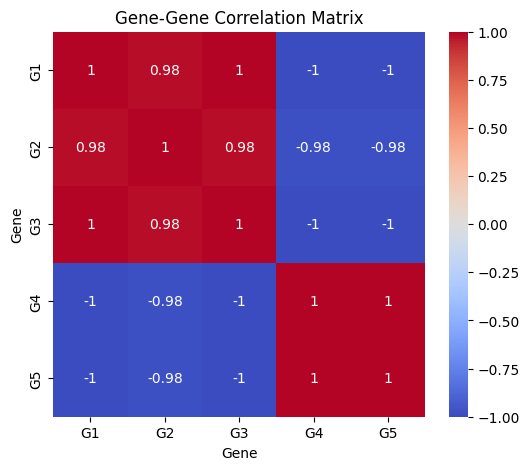

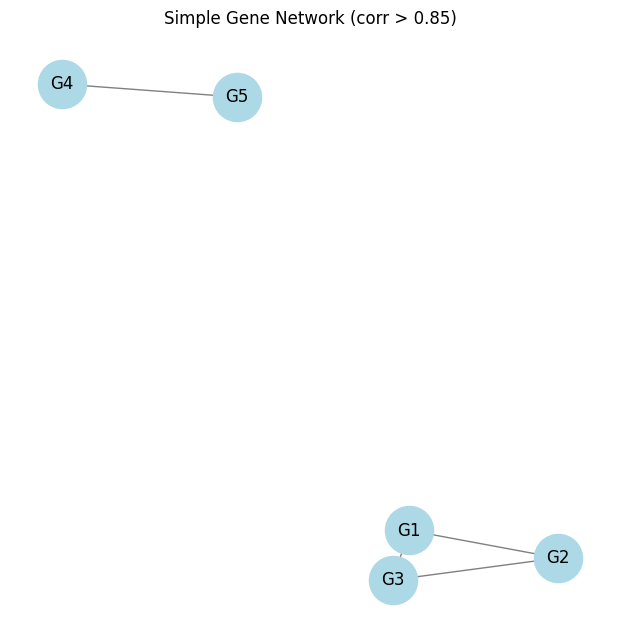

In [ ]:
# --- Simple Genetic Network Visualization Exercise ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# 1. Create a tiny synthetic gene expression dataset
data = {
    "Gene": ["G1", "G2", "G3", "G4", "G5"],
    "T1": [5, 2, 3, 8, 7],
    "T2": [6, 2, 4, 7, 6],
    "T3": [7, 3, 5, 6, 5],
    "T4": [8, 4, 6, 5, 4],
    "T5": [9, 5, 7, 4, 3],
    "T6": [10, 6, 8, 3, 2]
}

df = pd.DataFrame(data).set_index("Gene")

# 2. Heatmap of gene expression
plt.figure(figsize=(8, 5))
sns.heatmap(df, cmap="viridis", annot=True)
plt.title("Gene Expression Heatmap")
plt.show()

# 3. Correlation matrix
corr = df.T.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, cmap="coolwarm", annot=True, vmin=-1, vmax=1)
plt.title("Gene-Gene Correlation Matrix")
plt.show()

# 4. Build a simple network graph using correlation threshold
threshold = 0.85
edges = [(g1, g2) for g1 in corr.columns for g2 in corr.columns
         if g1 != g2 and corr.loc[g1, g2] > threshold]

G = nx.Graph()
G.add_nodes_from(corr.columns)
G.add_edges_from(edges)

plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=1200, edge_color="gray")
plt.title(f"Simple Gene Network (corr > {threshold})")
plt.show()
